# Using FishEnrichR for GSEA/pathway analysis

- last updated: 11/21/2024
- reference: https://maayanlab.cloud/FishEnrichr/help#api

### Step 1. analyze gene list
list of genes as the input, and returns JSON object with unique ID for analysis results

params:
- list: Newline-separated list of gene symbols to enrich
- description (optional)	String describing what the gene symbols represent

In [15]:
import json
import requests
import pandas as pd

In [27]:
# Read the file into a Series, removing any empty lines
filepath = "/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/zebrahub-multiome-analysis/notebooks/Fig2_ATAC_RNA_correlation_metacells/gene_lists_by_cluster_leiden_0_7/cluster_0_genes.txt"
genes = pd.read_csv(filepath, header=None, skip_blank_lines=True, index_col=0)

# convert the df to a list (of genes)
list_genes = genes.index.to_list()

In [28]:
# Analyze the gene list
ENRICHR_URL = 'http://maayanlab.cloud/FishEnrichr/addList'
# genes_str = '\n'.join([
#     'PHF14', 'RBM3', 'MSL1', 'PHF21A', 'ARL10', 'INSR', 'JADE2', 'P2RX7',
#     'LINC00662', 'CCDC101', 'PPM1B', 'KANSL1L', 'CRYZL1', 'ANAPC16', 'TMCC1',
#     'CDH8', 'RBM11', 'CNPY2', 'HSPA1L', 'CUL2', 'PLBD2', 'LARP7', 'TECPR2', 
#     'ZNF302', 'CUX1', 'MOB2', 'CYTH2', 'SEC22C', 'EIF4E3', 'ROBO2',
#     'ADAMTS9-AS2', 'CXXC1', 'LINC01314', 'ATF7', 'ATP5F1'
# ])
genes_str = '\n'.join(list_genes)
description = 'Example gene list'
payload = {
    'list': (None, genes_str),
    'description': (None, description)
}

response = requests.post(ENRICHR_URL, files=payload)
if not response.ok:
    raise Exception('Error analyzing gene list')

data = json.loads(response.text)
print(data)

{'shortId': 'c5d7021bc47574a8949e76cafdca47ce', 'userListId': 60555}


In [29]:
# View added gene list
ENRICHR_URL = 'http://maayanlab.cloud/FishEnrichr/view?userListId=%s'
user_list_id = 60555
response = requests.get(ENRICHR_URL % user_list_id)
if not response.ok:
    raise Exception('Error getting gene list')
    
data = json.loads(response.text)
print(data)

{'genes': ['notch1a', 'kalrnb', 'prxl2b', 'lpcat1', 'rbp5', 'zbtb16a', 'numbl', 'rnd3a', 'si:dkey-117m1.4', 'nuak1b', 'atf3', 'snd1', 'acsl2', 'rfx2', 'myl10', 'si:ch211-166a6.5', 'qsox2', 'tiam2a', 'rab5b', 'foxo3b', 'mt-nd1', 'abcb6a', 'lrba', 'tmsb1', 'zgc:92140', 'adck1', 'tead1b', 'tead1a', 'gli2a', 'slc39a10', 'slc39a14', 'tnikb', 'st6gal2a', 'tiam1a', 'zgc:195170', 'ulk1a', 'wnk4b', 'aacs', 'glceb', 'tpst1', 'pxdn', 'pkdcca', 'ulk1b', 'rgs12a', 'smyd3', 'phlda3', 'sox9b', 'dmrt1', 'cep85l', 'itpk1b', 'mgat5', 'MDFI', 'bbc3', 'samd11', 'pcbp4', 'pot1', 'dock4b', 'kidins220a', 'sec61a1l', 'CU457819.1', 'scml2', 'fryb', 'ptprsa.1', 'rnf217', 'SLC39A11', 'coro1ca', 'plxna2', 'plxna3', 'plxnb1a', 'si:dkey-261m9.12', 'krt18a.1', 'fryl', 'ypel1', 'nrp1a', 'id2a', 'id2b', 'mef2aa', 'antxr1c', 'lzts2a', 'plxnb3', 'mpp5a', 'fam49al', 'nedd9', 'magi2a', 'bmpr1ab', 'sardh', 'nrbp2a', 'slit2', 'nphp4', 'cttnbp2nlb', 'hipk3b', 'msh6', 'sult2st1', 'bmpr1ba', 'elmo1', 'pgfb', 'fgf22', 'pkp4', '

In [30]:
# Get enrichment results
ENRICHR_URL = 'http://maayanlab.cloud/FishEnrichr/enrich'
query_string = '?userListId=%s&backgroundType=%s'
user_list_id = 60555
gene_set_library = 'WikiPathways_2018'
response = requests.get(
    ENRICHR_URL + query_string % (user_list_id, gene_set_library)
 )
if not response.ok:
    raise Exception('Error fetching enrichment results')

data = json.loads(response.text)
print(data)

{'WikiPathways_2018': [[1, 'BMP signaling pathway_WP211', 1.7255612507589274e-06, -1.8820322332903459, 24.97448906237608, ['bmp4', 'smad6b', 'bmpr1ab', 'bambia', 'tbx2b', 'zeb1b', 'bmpr2b', 'msx3', 'smad1', 'nog1', 'id3', 'glula', 'smad7'], 0.00010525923629629457, 0.00013969902453039496, 0.008521640496354092], [2, 'Canonical wnt signaling_WP566', 3.756975499857545e-05, -1.7649939725220094, 17.98407288674149, ['bmp4', 'eda', 'tcf7l1a', 'tcf7l1b', 'tle3b', 'otx1', 'prkcbb', 'sox9b', 'fzd8a', 'tcf7l2', 'inhbb', 'fzd10', 'nkd1', 'axin2', 'id2b', 'id2a', 'cited4b', 'dld'], 0.0011458775274565513, 0.0021540474172095665, 0.06569844622489178], [3, 'Transformation Growth Factor (TGF) beta Receptor Signaling Pathway_WP1367', 0.0005583106041289172, -1.5116353378492158, 11.323048273159449, ['zeb2a', 'smad6b', 'skia', 'camk2b1', 'tp53', 'atf3', 'prkcbb', 'foxo3b', 'stambpl1', 'zeb1b', 'axin2', 'mef2aa', 'fosab', 'smad7'], 0.011352315617287981, 0.011922407903109378, 0.24242229402989068], [4, 'Id Sign

In [32]:
# Find GO terms that contain a given gene
# ENRICHR_URL = 'http://maayanlab.cloud/FishEnrichr/genemap'
# query_string = '?json=true&setup=true&gene=%s'
# gene = 'bmp4'
# response = requests.get(ENRICHR_URL + query_string % gene)
# if not response.ok:
#     raise Exception('Error searching for terms')
    
# data = json.loads(response.text)
# print(data)

In [33]:
# Download file of enrichment results
ENRICHR_URL = 'http://maayanlab.cloud/FishEnrichr/export'
query_string = '?userListId=%s&filename=%s&backgroundType=%s'
user_list_id = 60555
filename = 'cluster_0'
gene_set_library = 'WikiPathways_2018'

url = ENRICHR_URL + query_string % (user_list_id, filename, gene_set_library)
response = requests.get(url, stream=True)

with open(filename + '.txt', 'wb') as f:
    for chunk in response.iter_content(chunk_size=1024): 
        if chunk:
            f.write(chunk)

## converted the above code cells into a module/script in utils


In [37]:
import sys
import os
sys.path.append('/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/zebrahub-multiome-analysis/scripts/utils/')
from FishEnrichR import *

In [38]:
# go through the gene_lists from each leiden cluster, then run FishEnrichR, and save the results

# Set up input and output directories 
input_dir = "/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/zebrahub-multiome-analysis/notebooks/Fig2_ATAC_RNA_correlation_metacells/gene_lists_by_cluster_leiden_0_7"
output_dir = os.path.join(os.path.dirname(input_dir), "FishEnrichR_wikipathways_2018")

# Create output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Initialize FishEnrichR
enrichr = FishEnrichR()

# Process each cluster file
for filename in os.listdir(input_dir):
    if filename.startswith('cluster_') and filename.endswith('_genes.txt'):
        # Get cluster number for naming output
        cluster_num = filename.split('_')[1]

        # Full path to input file
        filepath = os.path.join(input_dir, filename)

        print(f"Processing cluster {cluster_num}...")

        # Read and analyze genes
        genes = pd.read_csv(filepath, header=None, skip_blank_lines=True, index_col=0)
        # convert the df to a list (of genes)
        genes = genes.index.to_list()

        result = enrichr.analyze_genes(genes, f"Cluster {cluster_num} genes")

        # Get enrichment results and save to file 
        user_list_id = result['userListId']
        output_filename = f"cluster_{cluster_num}_enrichment"
        output_path = os.path.join(output_dir, output_filename)

        enrichr.download_results(user_list_id, output_path, 'WikiPathways_2018')
        print(f"Saved results for cluster {cluster_num}")

Processing cluster 3...
Saved results for cluster 3
Processing cluster 8...
Saved results for cluster 8
Processing cluster 4...
Saved results for cluster 4
Processing cluster 6...
Saved results for cluster 6
Processing cluster 13...
Saved results for cluster 13
Processing cluster 1...
Saved results for cluster 1
Processing cluster 0...
Saved results for cluster 0
Processing cluster 11...
Saved results for cluster 11
Processing cluster 7...
Saved results for cluster 7
Processing cluster 2...
Saved results for cluster 2
Processing cluster 9...
Saved results for cluster 9
Processing cluster 10...
Saved results for cluster 10
Processing cluster 5...
Saved results for cluster 5
Processing cluster 12...
Saved results for cluster 12


### plotting the enrichment result using a bar plot

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
def plot_pathway_enrichment(file_path, output_path, top_n=10):
    # Read the tab-separated file
    df = pd.read_csv(file_path, sep='\t')
    
    # Sort by Combined Score and get top N pathways
    df = df.sort_values('Combined Score', ascending=True).tail(top_n)
    
    # Create color list based on p-value
    colors = ['grey' if p > 0.05 else 'purple' for p in df['P-value']]
    
    # Create the plot
    plt.figure(figsize=(12, 8))
    bars = plt.barh(df['Term'], df['Combined Score'], color=colors, alpha=0.6)
    
    # Customize the plot
    plt.title('WikiPathways 2018 Enrichment', fontsize=14, pad=20)
    plt.xlabel('Combined Score', fontsize=12)
    
    # Remove pathway prefix for cleaner labels
    plt.yticks(range(len(df['Term'])), 
              [term.split('_WP')[0] for term in df['Term']], 
              fontsize=10)
    
    # Add significance legend
    plt.legend([plt.Rectangle((0,0),1,1, fc='purple', alpha=0.6),
               plt.Rectangle((0,0),1,1, fc='grey', alpha=0.6)],
              ['p < 0.05', 'p > 0.05'])
    
    # Adjust layout and save
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.close()

In [43]:
# Example usage:
base_dir = "/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/zebrahub-multiome-analysis/notebooks/Fig2_ATAC_RNA_correlation_metacells/FishEnrichR_wikipathways_2018/"
for i in range(14):  # For clusters 0-13
    input_file = f"{base_dir}/cluster_{i}_enrichment.txt"
    output_file = f"{base_dir}/cluster_{i}_pathways.png"
    plot_pathway_enrichment(input_file, output_file)

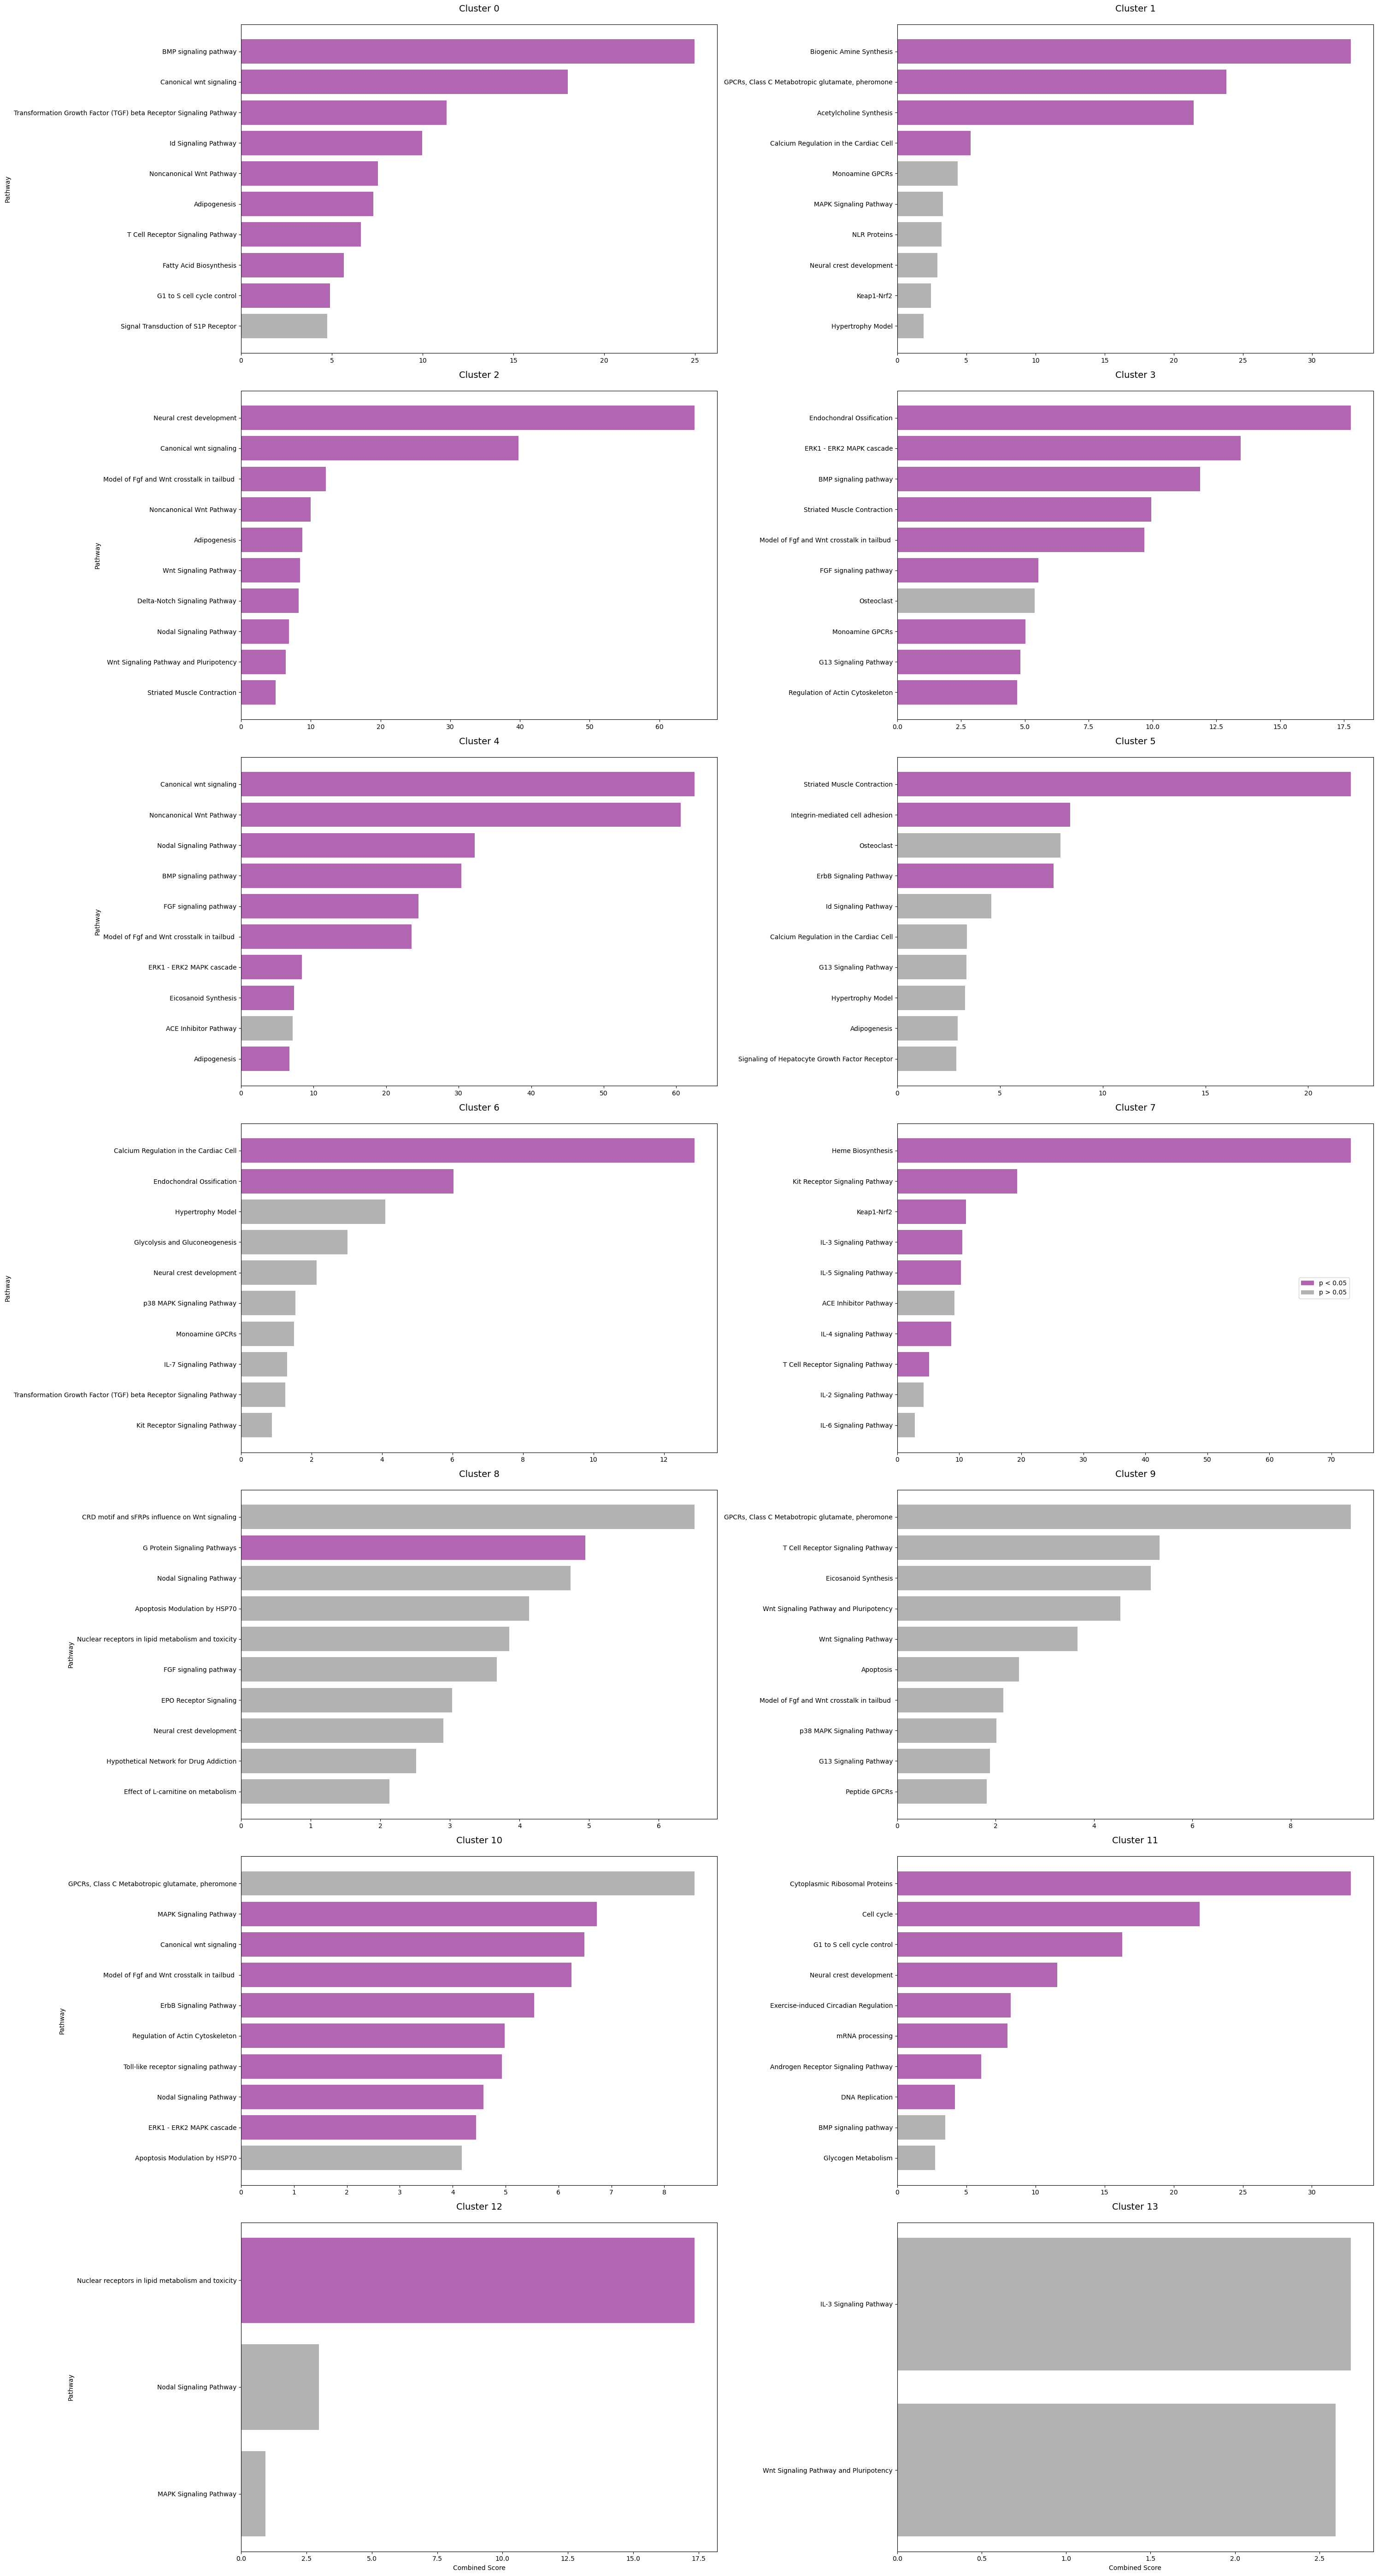

In [44]:
# Set up figure
ncols = 2
nrows = 7
fig = plt.figure(figsize=(15*ncols, 8*nrows))

# Base directory
base_dir = "/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/zebrahub-multiome-analysis/notebooks/Fig2_ATAC_RNA_correlation_metacells/FishEnrichR_wikipathways_2018/"

# Plot for each cluster
for i in range(14):
   # Read data
   input_file = f"{base_dir}/cluster_{i}_enrichment.txt"
   df = pd.read_csv(input_file, sep='\t')
   df = df.sort_values('Combined Score', ascending=True).tail(10)  # Get top 10
   
   # Create colors based on p-value
   colors = ['grey' if p > 0.05 else 'purple' for p in df['P-value']]
   
   # Create subplot
   ax = plt.subplot(nrows, ncols, i+1)
   
   # Create horizontal bars
   bars = ax.barh(df['Term'], df['Combined Score'], color=colors, alpha=0.6)
   
   # Customize subplot
   ax.set_title(f'Cluster {i}', fontsize=14, pad=20)
   if i % ncols == 0:  # Only show y-label for leftmost plots
       ax.set_ylabel('Pathway')
   if i >= 12:  # Only show x-label for bottom plots
       ax.set_xlabel('Combined Score')
   
   # Clean pathway names and set yticks
   ax.set_yticks(range(len(df['Term'])))
   ax.set_yticklabels([term.split('_WP')[0] for term in df['Term']], fontsize=10)

# Add legend
legend_elements = [plt.Rectangle((0,0),1,1, fc='purple', alpha=0.6),
                 plt.Rectangle((0,0),1,1, fc='grey', alpha=0.6)]
fig.legend(legend_elements, ['p < 0.05', 'p > 0.05'], 
         loc='center right', bbox_to_anchor=(0.98, 0.5))

# Adjust layout and save
plt.tight_layout()
plt.show()
# plt.savefig(f'{base_dir}/all_clusters_pathways.png', dpi=300, bbox_inches='tight')
# plt.close()

In [50]:
import logging

# Set the logging level to WARN, filtering out informational messages
logging.getLogger().setLevel(logging.WARNING)

import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault) #Reset rcParams to default

# Set the default font to Arial
mpl.rcParams['font.family'] = 'Arial'

# If Arial is not available on your system, you might need to specify an alternative or ensure Arial is installed.
# On some systems, you might need to use 'font.sans-serif' as a fallback option:
# mpl.rcParams['font.sans-serif'] = 'Arial'

# Editable text and proper LaTeX fonts in illustrator
# matplotlib.rcParams['ps.useafm'] = True
# Editable fonts. 42 is the magic number for editable text in PDFs
mpl.rcParams['pdf.fonttype'] = 42
sns.set(style='whitegrid', context='paper')

# Plotting style function (run this before plotting the final figure)
def set_plotting_style():
    plt.style.use('seaborn-paper')
    plt.rc('axes', labelsize=12)
    plt.rc('axes', titlesize=12)
    plt.rc('xtick', labelsize=10)
    plt.rc('ytick', labelsize=10)
    plt.rc('legend', fontsize=10)
    plt.rc('text.latex', preamble=r'\usepackage{sfmath}')
    plt.rc('xtick.major', pad=2)
    plt.rc('ytick.major', pad=2)
    plt.rc('mathtext', fontset='stixsans', sf='sansserif')
    plt.rc('figure', figsize=[10,9])
    plt.rc('svg', fonttype='none')

    # Override any previously set font settings to ensure Arial is used
    plt.rc('font', family='Arial')

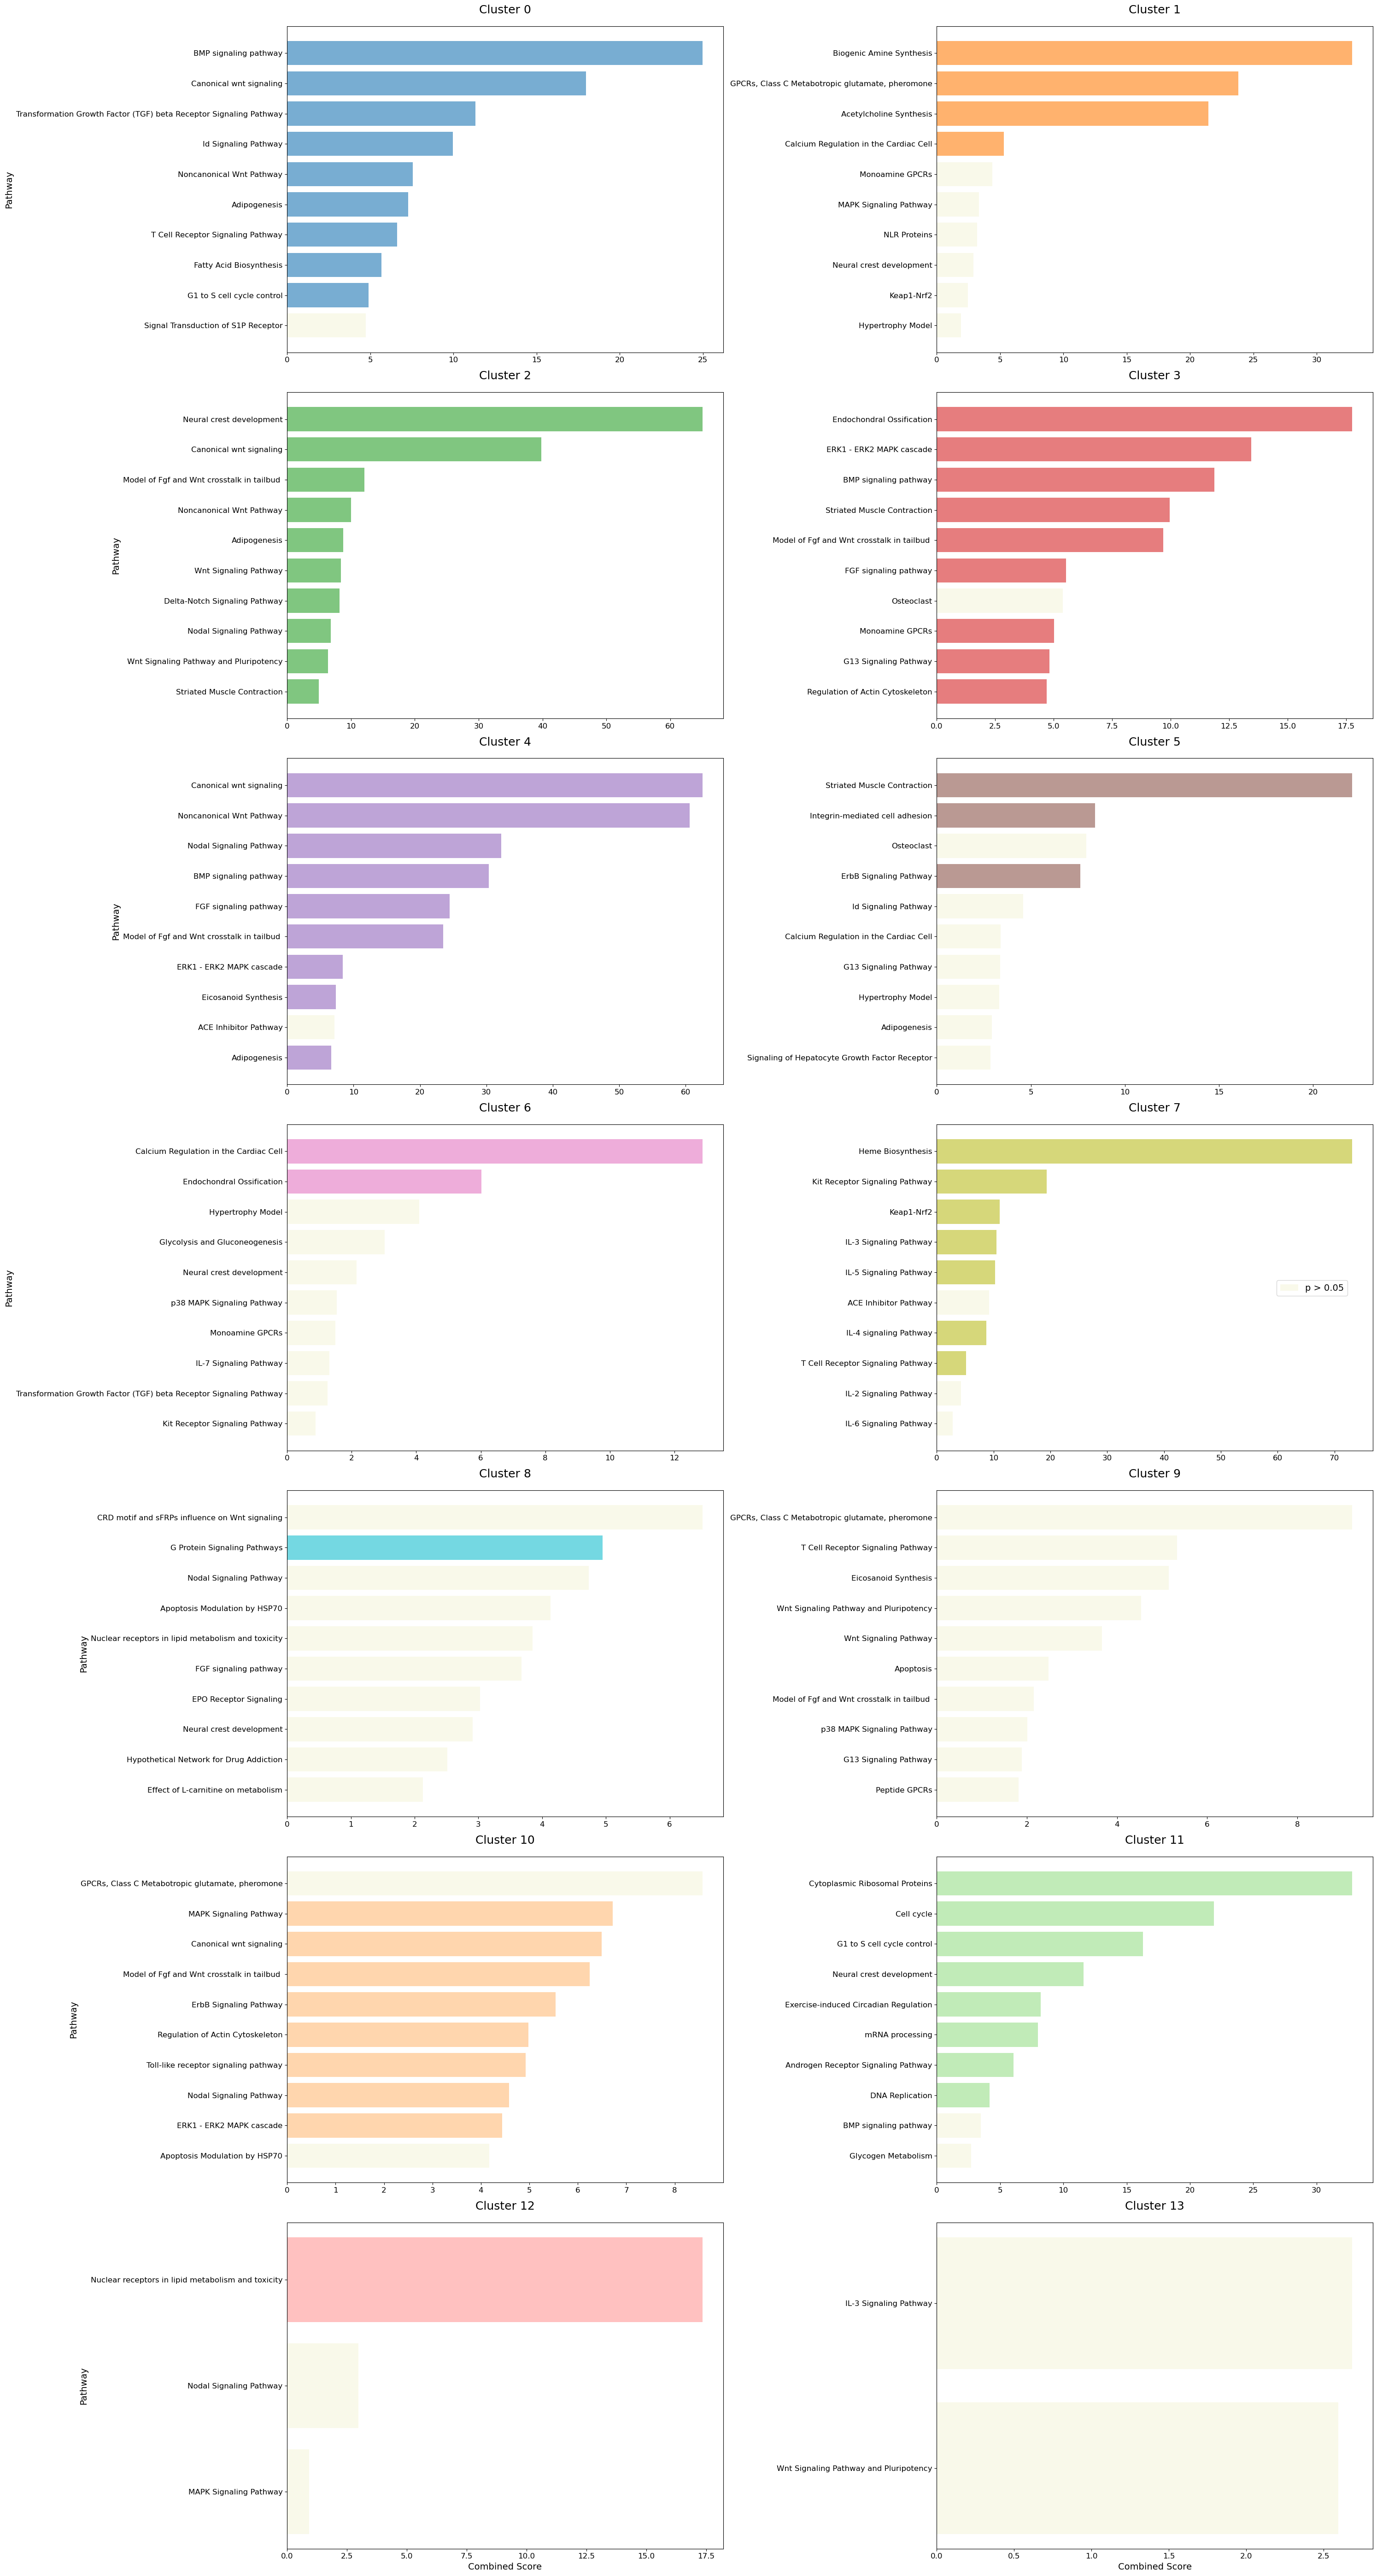

In [49]:
# Set font sizes
TITLE_SIZE = 18
LABEL_SIZE = 14
TICK_SIZE = 12
LEGEND_SIZE = 14

# Set up figure
ncols = 2
nrows = 7
fig = plt.figure(figsize=(15*ncols, 8*nrows))

# Base directory
base_dir = "/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/zebrahub-multiome-analysis/notebooks/Fig2_ATAC_RNA_correlation_metacells/FishEnrichR_wikipathways_2018/"

# Define color map matching the UMAP
cluster_colors = {
    0: '#1f77b4',  # blue
    1: '#ff7f0e',  # orange
    2: '#2ca02c',  # green
    3: '#d62728',  # red
    4: '#9467bd',  # purple
    5: '#8c564b',  # brown
    6: '#e377c2',  # pink
    7: '#bcbd22',  # olive
    8: '#17becf',  # cyan
    9: '#aec7e8',  # light blue
    10: '#ffbb78', # light orange
    11: '#98df8a', # light green
    12: '#ff9896', # light red
    13: '#c5b0d5'  # light purple
}

# Define color for non-significant results
nonsig_color = '#F5F5DC'  # light beige

# Plot for each cluster
for i in range(14):
    # Read data
    input_file = f"{base_dir}/cluster_{i}_enrichment.txt"
    df = pd.read_csv(input_file, sep='\t')
    df = df.sort_values('Combined Score', ascending=True).tail(10)  # Get top 10
    
    # Create colors based on p-value
    colors = [nonsig_color if p > 0.05 else cluster_colors[i] for p in df['P-value']]
    
    # Create subplot
    ax = plt.subplot(nrows, ncols, i+1)
    
    # Create horizontal bars
    bars = ax.barh(df['Term'], df['Combined Score'], color=colors, alpha=0.6)
    
    # Customize subplot
    ax.set_title(f'Cluster {i}', fontsize=TITLE_SIZE, pad=20)
    if i % ncols == 0:  # Only show y-label for leftmost plots
        ax.set_ylabel('Pathway', fontsize=LABEL_SIZE)
    if i >= 12:  # Only show x-label for bottom plots
        ax.set_xlabel('Combined Score', fontsize=LABEL_SIZE)
    
    # Clean pathway names and set yticks
    ax.set_yticks(range(len(df['Term'])))
    ax.set_yticklabels([term.split('_WP')[0] for term in df['Term']], fontsize=TICK_SIZE)
    
    # Make x-axis tick labels larger
    ax.tick_params(axis='x', labelsize=TICK_SIZE)

# Add legend for significance
legend_elements = [plt.Rectangle((0,0),1,1, fc=nonsig_color, alpha=0.6)]
legend_labels = ['p > 0.05']
fig.legend(legend_elements, legend_labels, 
          loc='center right', bbox_to_anchor=(0.98, 0.5),
          fontsize=LEGEND_SIZE)

# Adjust layout and save
plt.tight_layout()
plt.savefig(f'{base_dir}/all_clusters_pathways.pdf', dpi=300, bbox_inches='tight')
plt.show()

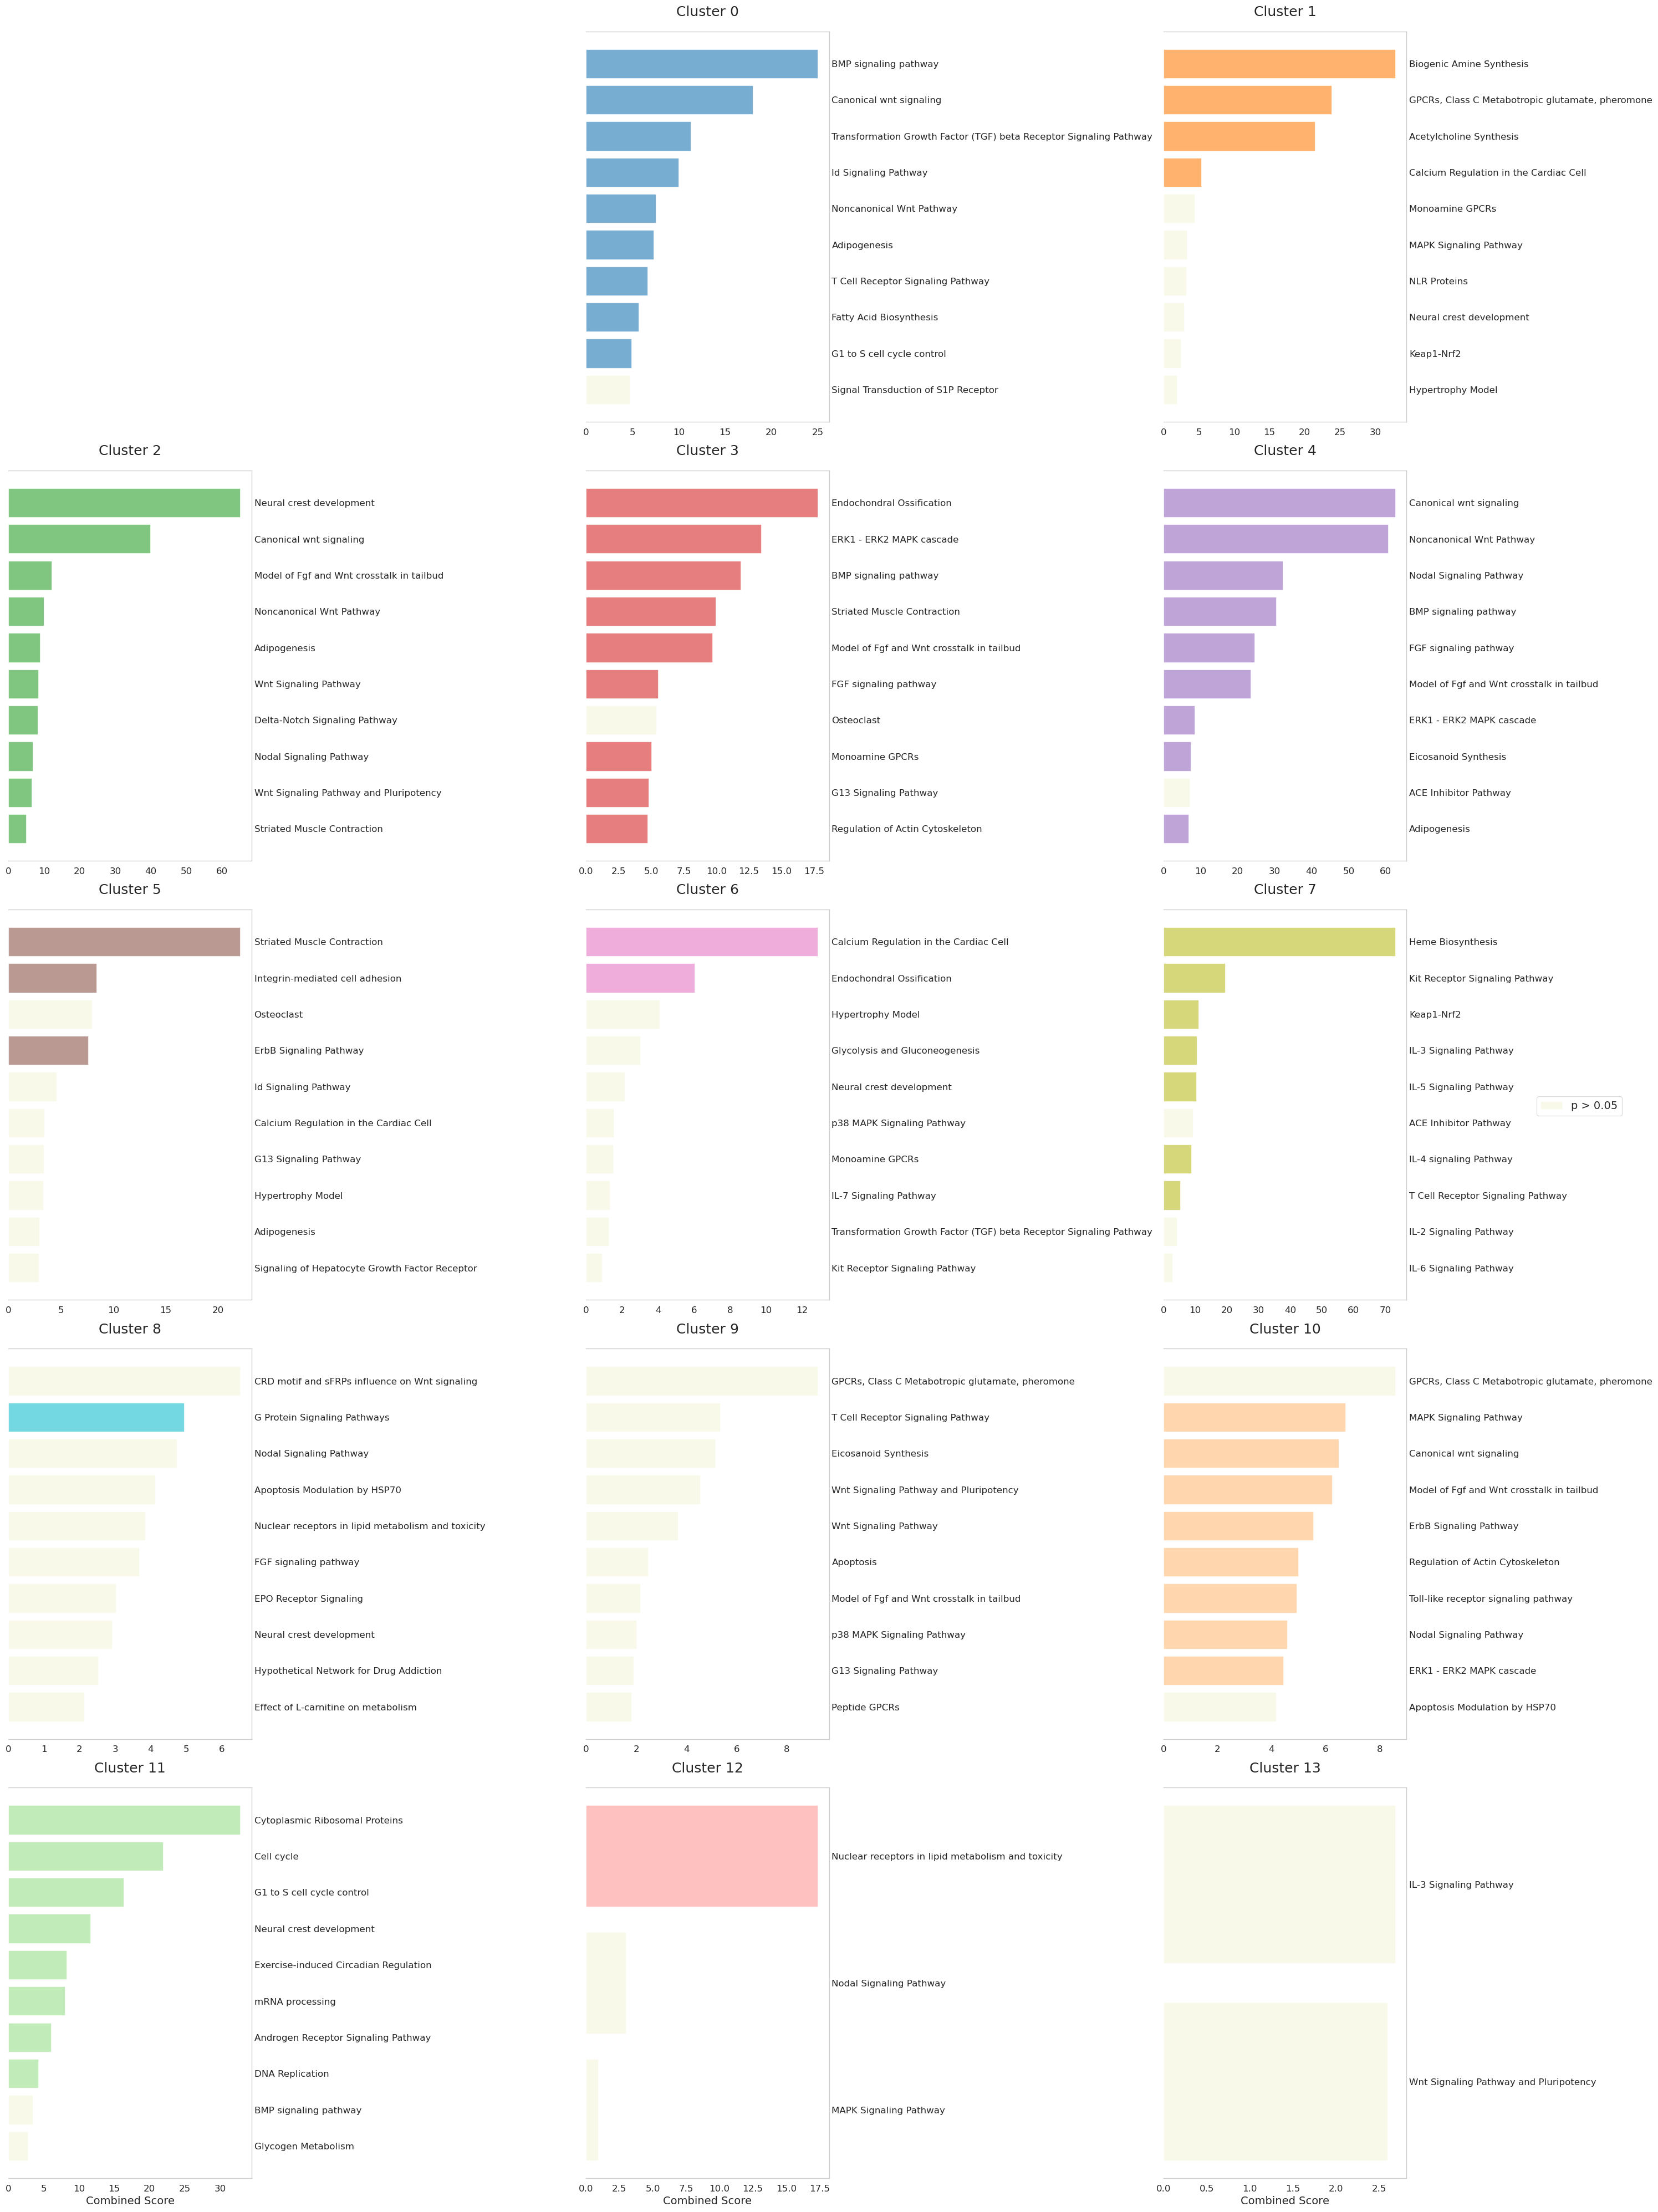

In [54]:
# Import libraries and setup as before...
ncols = 3
nrows = 5
fig = plt.figure(figsize=(15*2, 8*5))

# Plot for each cluster
for i in range(14):
    # Calculate subplot position
    if i < 2:
        # First row: plots in positions 2 and 3
        subplot_pos = i + 2
    else:
        # Subsequent rows: normal order but shifted by 1
        subplot_pos = i + 2
    
    # Create subplot
    ax = plt.subplot(nrows, ncols, subplot_pos)
    
    # Read and process data
    input_file = f"{base_dir}/cluster_{i}_enrichment.txt"
    df = pd.read_csv(input_file, sep='\t')
    df = df.sort_values('Combined Score', ascending=True).tail(10)
    
    colors = [nonsig_color if p > 0.05 else cluster_colors[i] for p in df['P-value']]
    
    # Create horizontal bars
    bars = ax.barh(df['Term'], df['Combined Score'], color=colors, alpha=0.6)
    
    # Customize subplot
    ax.set_title(f'Cluster {i}', fontsize=TITLE_SIZE, pad=20)
    
    # Move the y-axis labels inside the plot
    ax.set_yticks(range(len(df['Term'])))
    ax.set_yticklabels([term.split('_WP')[0] for term in df['Term']], fontsize=TICK_SIZE)
    
    # Remove y-axis line and ticks
    ax.spines['left'].set_visible(False)
    ax.tick_params(axis='y', length=0)
    
    # Move labels inside by adjusting position
    ax.tick_params(axis='y', labelleft=False, labelright=True)
    
    # Add grid lines to help follow the bars
    # ax.grid(True, axis='x', linestyle='--', alpha=0.3)
    ax.grid(False)
    
    # Make x-axis tick labels larger
    ax.tick_params(axis='x', labelsize=TICK_SIZE)
    
    # Only add xlabel to bottom plots
    if subplot_pos > (nrows-1)*ncols:
        ax.set_xlabel('Combined Score', fontsize=LABEL_SIZE)

# Add legend for significance
legend_elements = [plt.Rectangle((0,0),1,1, fc=nonsig_color, alpha=0.6)]
legend_labels = ['p > 0.05']
fig.legend(legend_elements, legend_labels, 
          loc='center right', bbox_to_anchor=(0.98, 0.5),
          fontsize=LEGEND_SIZE)

# Adjust layout and save
plt.tight_layout()
plt.savefig(f'{base_dir}/all_clusters_pathways.pdf', dpi=300, bbox_inches='tight')
plt.show()

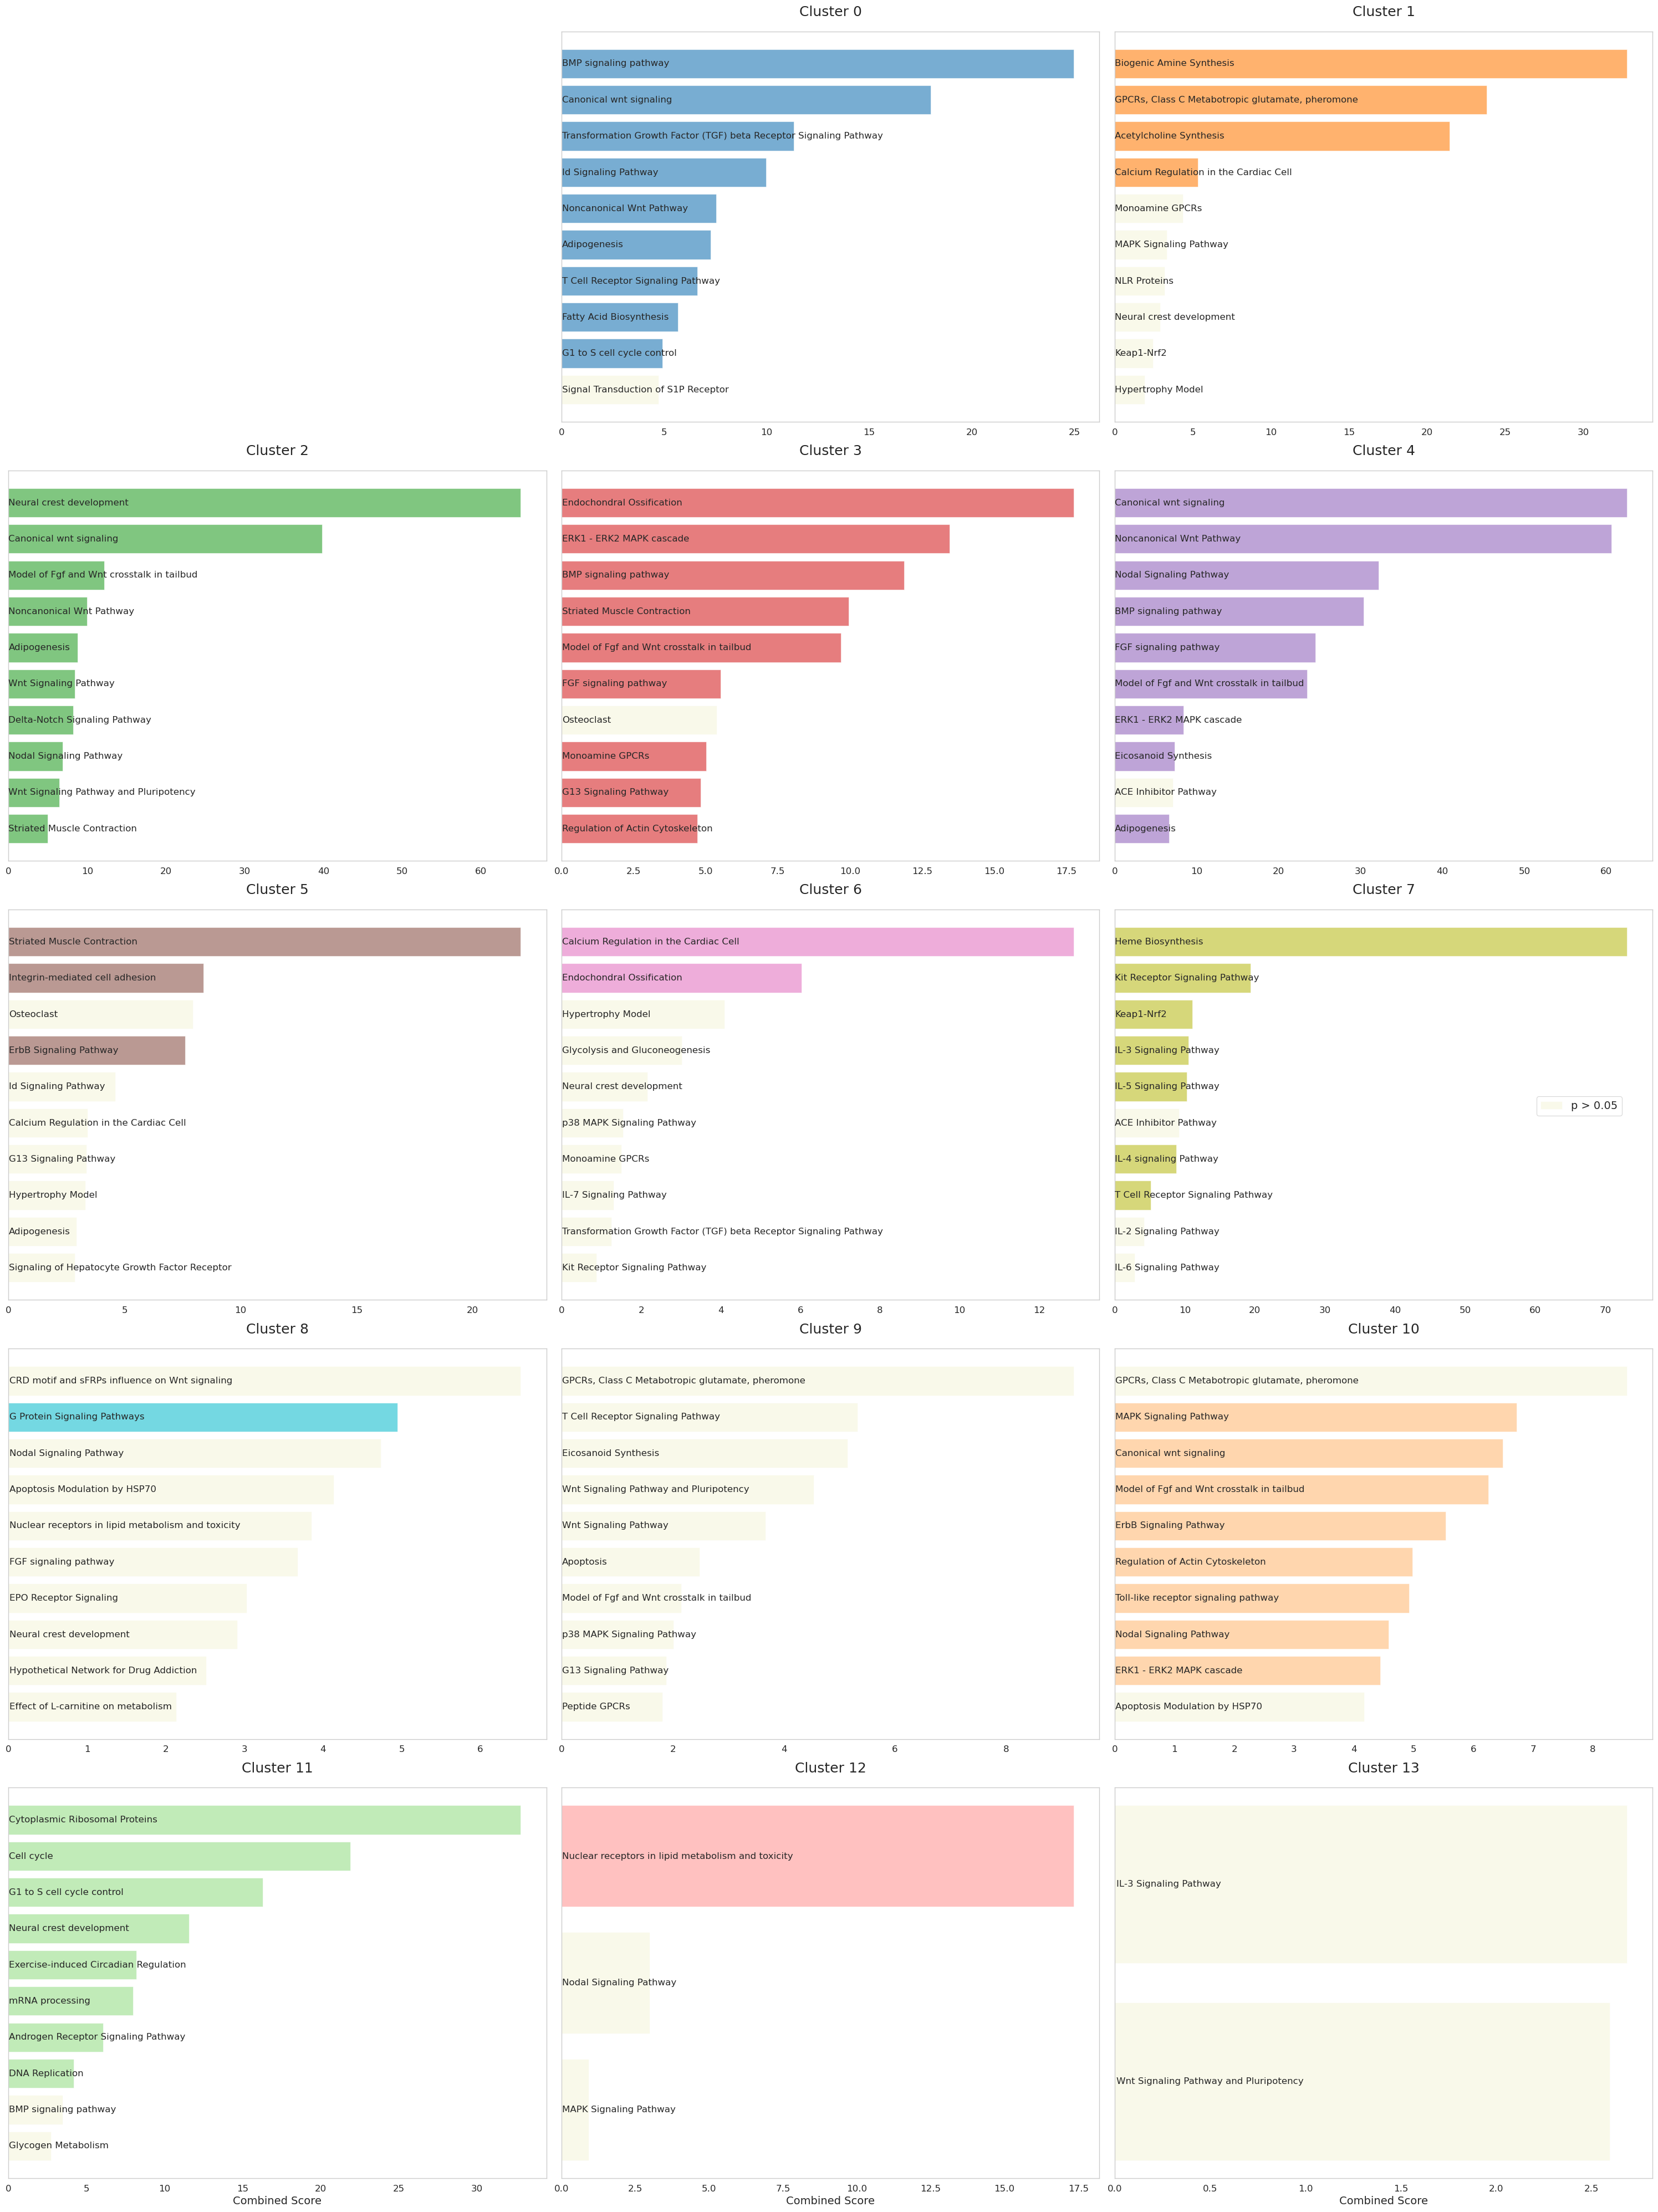

In [56]:
ncols = 3
nrows = 5
fig = plt.figure(figsize=(15*2, 8*5))

# Plot for each cluster
for i in range(14):
    # Calculate subplot position
    if i < 2:
        subplot_pos = i + 2
    else:
        subplot_pos = i + 2
    
    # Create subplot
    ax = plt.subplot(nrows, ncols, subplot_pos)
    
    # Read and process data
    input_file = f"{base_dir}/cluster_{i}_enrichment.txt"
    df = pd.read_csv(input_file, sep='\t')
    df = df.sort_values('Combined Score', ascending=True).tail(10)
    
    colors = [nonsig_color if p > 0.05 else cluster_colors[i] for p in df['P-value']]
    
    # Create horizontal bars
    bars = ax.barh(df['Term'], df['Combined Score'], color=colors, alpha=0.6)
    
    # Customize subplot
    ax.set_title(f'Cluster {i}', fontsize=TITLE_SIZE, pad=20)
    
    # Set y-ticks and labels
    ax.set_yticks(range(len(df['Term'])))
    
    # Add back the y-axis line
    ax.spines['left'].set_visible(True)
    
    # Remove original y-tick labels
    ax.set_yticklabels([])
    
    # Add labels on top of bars
    for idx, (term, value) in enumerate(zip(df['Term'], df['Combined Score'])):
        ax.text(0.01, idx, term.split('_WP')[0], 
                va='center', fontsize=TICK_SIZE,
                bbox=dict(facecolor="none", edgecolor='none', alpha=0.7))
    
    # Add grid lines to help follow the bars
    # ax.grid(True, axis='x', linestyle='--', alpha=0.3)
    ax.grid(False)
    
    # Make x-axis tick labels larger
    ax.tick_params(axis='x', labelsize=TICK_SIZE)
    
    # Only add xlabel to bottom plots
    if subplot_pos > (nrows-1)*ncols:
        ax.set_xlabel('Combined Score', fontsize=LABEL_SIZE)

# Add legend for significance
legend_elements = [plt.Rectangle((0,0),1,1, fc=nonsig_color, alpha=0.6)]
legend_labels = ['p > 0.05']
fig.legend(legend_elements, legend_labels, 
          loc='center right', bbox_to_anchor=(0.98, 0.5),
          fontsize=LEGEND_SIZE)

# Adjust layout and save
plt.tight_layout()
plt.savefig(f'{base_dir}/all_clusters_pathways.pdf', dpi=300, bbox_inches='tight')
plt.show()